# Decision Tree Regression

## Introduction

Decision tree regression is a machine learning technique that constructs a tree-like model to predict continuous numerical values. Unlike classification tasks where the output is categorical, decision tree regression focuses on estimating numeric outcomes.

## Working of the algorithm

**Building the Tree:**
At the core of decision tree regression lies a tree-like structure. Imagine you have a dataset with various attributes (features) and their corresponding target values. The algorithm begins by creating a root node that represents the entire dataset.

**Splitting the Data:**
The algorithm analyzes each feature to determine the best way to divide the data into distinct groups based on their target values. It does this by setting specific conditions or thresholds on the feature values. The split is designed to minimize the differences between target values within each group.

**Recursive Splitting:**
Once the first split is made, the algorithm creates two child nodes, representing subsets of the original data. Each child node embodies a particular range of values based on the split condition. The algorithm then repeats this process for each child node, recursively splitting the data further based on the best features and conditions.

**Stopping Criterion:**
The recursive splitting process continues until a stopping criterion is met. This criterion can be defined by a maximum depth limit, ensuring the tree doesn’t become too complex. Alternatively, it could be based on having a minimum number of data points in a leaf node, preventing overfitting.

**Making Predictions:**
To make a prediction for a new data point, the decision tree regression algorithm starts at the root node and follows a path down the tree based on the feature values of the data point. At each node, it checks the condition associated with that node and proceeds to the left or right child node accordingly. This traversal continues until a leaf node is reached.

**Final Prediction:**
The leaf node reached during the traversal contains a predicted value associated with it and that predicted value is average of actual values of the sub group. This value becomes the output of the decision tree regression algorithm for the given data point.

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Loading dataset

In [ ]:
data = pd.read_csv("/content/houseprice.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Columns: 108 entries, bath to location_Tumkur Road
dtypes: float64(5), int64(103)
memory usage: 5.9 MB


# Examining the dataset

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
data.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,location_Whitefield,location_Sarjapur Road,location_Electronic City,location_Marathahalli,location_Raja Rajeshwari Nagar,location_Haralur Road,location_Hennur Road,location_Bannerghatta Road,location_Uttarahalli,location_Thanisandra,location_Electronic City Phase II,location_Hebbal,location_7th Phase JP Nagar,location_Yelahanka,location_Kanakpura Road,location_KR Puram,location_Sarjapur,location_Rajaji Nagar,location_Kasavanhalli,location_Bellandur,location_Begur Road,location_Banashankari,location_Kothanur,location_Hormavu,location_Harlur,location_Akshaya Nagar,location_Jakkur,location_Electronics City Phase 1,location_Varthur,location_Chandapura,location_HSR Layout,location_Hennur,location_Ramamurthy Nagar,location_Ramagondanahalli,location_Kaggadasapura,location_Kundalahalli,location_Koramangala,location_Hulimavu,location_Budigere,location_Hoodi,location_Malleshwaram,location_Hegde Nagar,location_8th Phase JP Nagar,location_Gottigere,location_JP Nagar,location_Yeshwanthpur,location_Channasandra,location_Bisuvanahalli,location_Vittasandra,location_Indira Nagar,location_Vijayanagar,location_Kengeri,location_Brookefield,location_Sahakara Nagar,location_Hosa Road,location_Old Airport Road,location_Bommasandra,location_Balagere,location_Green Glen Layout,location_Old Madras Road,location_Rachenahalli,location_Panathur,location_Kudlu Gate,location_Thigalarapalya,location_Ambedkar Nagar,location_Jigani,location_Yelahanka New Town,location_Talaghattapura,location_Mysore Road,location_Kadugodi,location_Frazer Town,location_Dodda Nekkundi,location_Devanahalli,location_Kanakapura,location_Attibele,location_Anekal,location_Lakshminarayana Pura,location_Nagarbhavi,location_Ananth Nagar,location_5th Phase JP Nagar,location_TC Palaya,location_CV Raman Nagar,location_Kengeri Satellite Town,location_Kudlu,location_Jalahalli,location_Subramanyapura,location_Bhoganhalli,location_Doddathoguru,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
0,3.0,2.0,150.0,1672.0,3,8971.291866,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,3.0,3.0,149.0,1750.0,3,8514.285714,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3.0,2.0,150.0,1750.0,3,8571.428571,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2.0,2.0,40.0,1250.0,2,3200.000000,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2.0,2.0,83.0,1200.0,2,6916.666667,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.tail()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,location_Whitefield,location_Sarjapur Road,location_Electronic City,location_Marathahalli,location_Raja Rajeshwari Nagar,location_Haralur Road,location_Hennur Road,location_Bannerghatta Road,location_Uttarahalli,location_Thanisandra,location_Electronic City Phase II,location_Hebbal,location_7th Phase JP Nagar,location_Yelahanka,location_Kanakpura Road,location_KR Puram,location_Sarjapur,location_Rajaji Nagar,location_Kasavanhalli,location_Bellandur,location_Begur Road,location_Banashankari,location_Kothanur,location_Hormavu,location_Harlur,location_Akshaya Nagar,location_Jakkur,location_Electronics City Phase 1,location_Varthur,location_Chandapura,location_HSR Layout,location_Hennur,location_Ramamurthy Nagar,location_Ramagondanahalli,location_Kaggadasapura,location_Kundalahalli,location_Koramangala,location_Hulimavu,location_Budigere,location_Hoodi,location_Malleshwaram,location_Hegde Nagar,location_8th Phase JP Nagar,location_Gottigere,location_JP Nagar,location_Yeshwanthpur,location_Channasandra,location_Bisuvanahalli,location_Vittasandra,location_Indira Nagar,location_Vijayanagar,location_Kengeri,location_Brookefield,location_Sahakara Nagar,location_Hosa Road,location_Old Airport Road,location_Bommasandra,location_Balagere,location_Green Glen Layout,location_Old Madras Road,location_Rachenahalli,location_Panathur,location_Kudlu Gate,location_Thigalarapalya,location_Ambedkar Nagar,location_Jigani,location_Yelahanka New Town,location_Talaghattapura,location_Mysore Road,location_Kadugodi,location_Frazer Town,location_Dodda Nekkundi,location_Devanahalli,location_Kanakapura,location_Attibele,location_Anekal,location_Lakshminarayana Pura,location_Nagarbhavi,location_Ananth Nagar,location_5th Phase JP Nagar,location_TC Palaya,location_CV Raman Nagar,location_Kengeri Satellite Town,location_Kudlu,location_Jalahalli,location_Subramanyapura,location_Bhoganhalli,location_Doddathoguru,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
7115,3.0,2.0,325.00,2900.0,3,11206.896552,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7116,3.0,1.0,84.83,1780.0,3,4765.730337,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7117,2.0,1.0,48.00,880.0,2,5454.545455,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7118,2.0,1.0,55.00,1000.0,2,5500.000000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7119,2.0,1.0,78.00,1400.0,3,5571.428571,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = data.iloc[:,:10]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   bath                           7120 non-null   float64
 1   balcony                        7120 non-null   float64
 2   price                          7120 non-null   float64
 3   total_sqft_int                 7120 non-null   float64
 4   bhk                            7120 non-null   int64  
 5   price_per_sqft                 7120 non-null   float64
 6   area_typeSuper built-up  Area  7120 non-null   int64  
 7   area_typeBuilt-up  Area        7120 non-null   int64  
 8   area_typePlot  Area            7120 non-null   int64  
 9   availability_Ready To Move     7120 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 556.4 KB


In [ ]:
data.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move
0,3.0,2.0,150.0,1672.0,3,8971.291866,1,0,0,1
1,3.0,3.0,149.0,1750.0,3,8514.285714,0,1,0,1
2,3.0,2.0,150.0,1750.0,3,8571.428571,1,0,0,1
3,2.0,2.0,40.0,1250.0,2,3200.000000,1,0,0,1
4,2.0,2.0,83.0,1200.0,2,6916.666667,0,0,1,1


In [ ]:
data.describe()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move
count,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000
mean,2.390871,1.572759,96.454991,1479.729806,2.465169,5923.806855,0.750702,0.182303,0.061938,0.792697
std,0.876822,0.770583,116.185034,913.779769,0.841520,2556.650935,0.432637,0.386121,0.241060,0.405403
min,1.000000,0.000000,10.000000,350.000000,1.000000,1250.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,49.230000,1100.000000,2.000000,4416.761042,1.000000,0.000000,0.000000,1.000000
50%,2.000000,2.000000,69.000000,1255.000000,2.000000,5417.855613,1.000000,0.000000,0.000000,1.000000
75%,3.000000,2.000000,104.000000,1640.250000,3.000000,6618.285651,1.000000,0.000000,0.000000,1.000000
max,9.000000,3.000000,2912.000000,30400.000000,9.000000,35000.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
data.shape

(7120, 10)

In [ ]:
data.isnull().sum()

,0
bath,0
balcony,0
price,0
total_sqft_int,0
bhk,0
price_per_sqft,0
area_typeSuper built-up Area,0
area_typeBuilt-up Area,0
area_typePlot Area,0
availability_Ready To Move,0


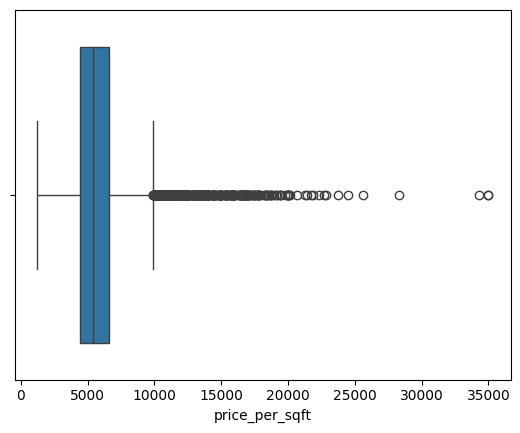

In [ ]:
# Boxplot of price per sqft
sns.boxplot(x=data['price_per_sqft'])
plt.show()

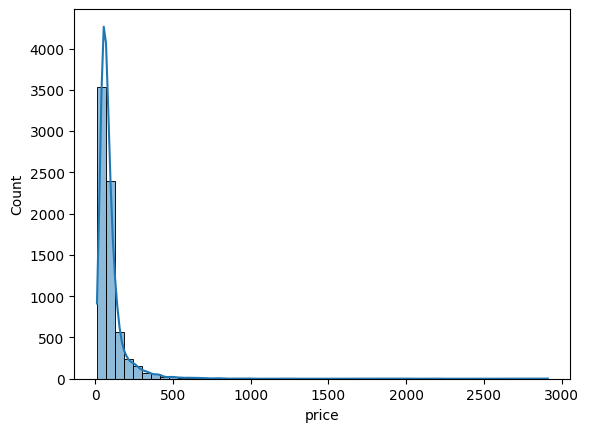

In [ ]:
# Histogram of price
sns.histplot(data['price'], bins=50, kde=True)
plt.show()

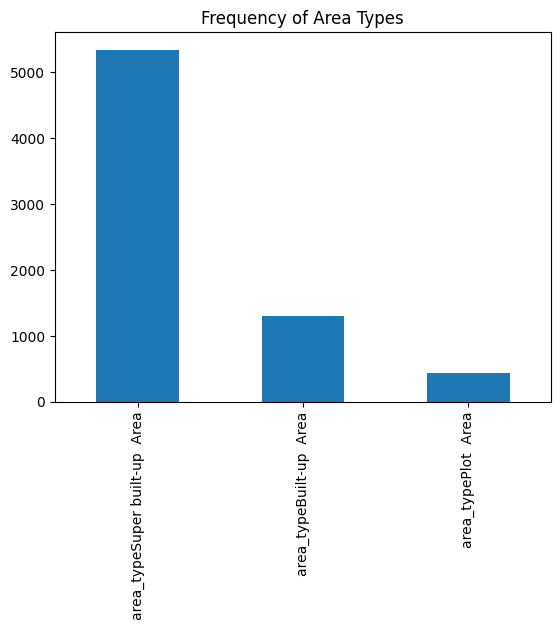

In [ ]:
area_cols = ['area_typeSuper built-up  Area',
             'area_typeBuilt-up  Area',
             'area_typePlot  Area']

data[area_cols].sum().plot(kind='bar')
plt.title("Frequency of Area Types")
plt.show()

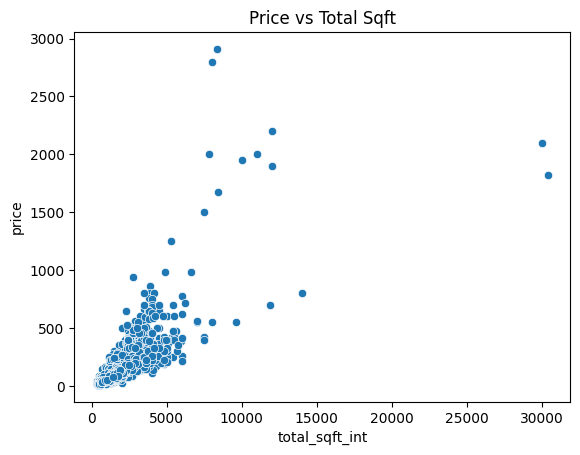

In [ ]:
sns.scatterplot(x='total_sqft_int', y='price', data=data)
plt.title("Price vs Total Sqft")
plt.show()

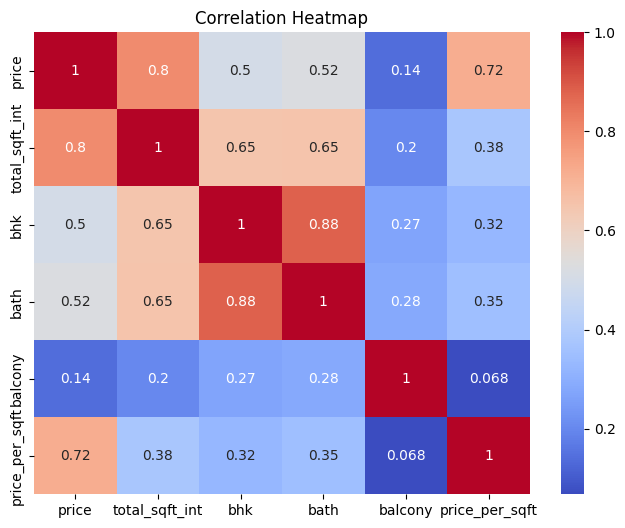

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data[['price','total_sqft_int','bhk','bath','balcony','price_per_sqft']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

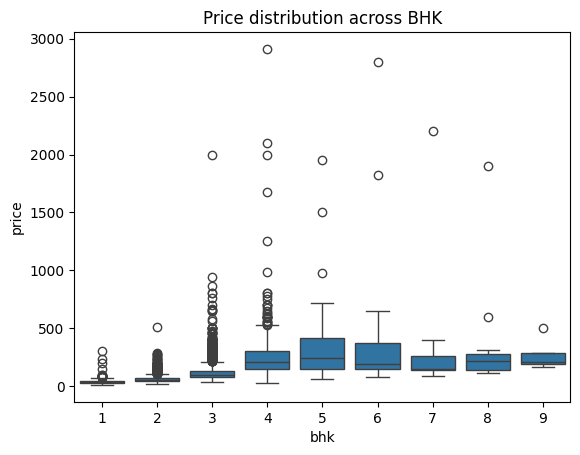

In [ ]:
sns.boxplot(x='bhk', y='price', data=data)
plt.title("Price distribution across BHK")
plt.show()

In [ ]:
features_to_plot = [ 'bath', 'balcony', 'price', 'total_sqft_int', 'bhk', 'price_per_sqft', 'area_typeSuper built-up  Area', 'area_typeBuilt-up  Area', 'area_typePlot  Area', 'availability_Ready To Move']
# Remove outliers beyond 3 standard deviations
for feature in features_to_plot:
    data = data[np.abs(data[feature] - data[feature].mean()) <= (3 * data[feature].std())]

df = data.reset_index(drop=True)

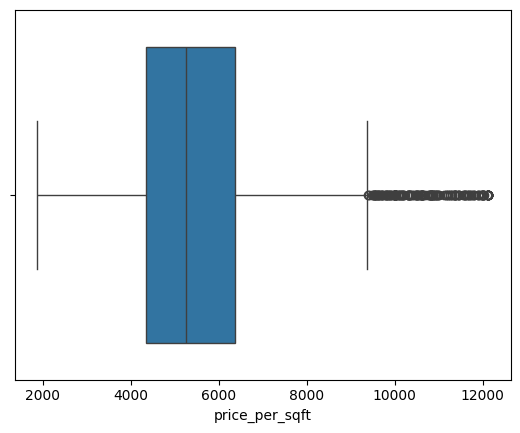

In [ ]:
# Boxplot of price per sqft
sns.boxplot(x=data['price_per_sqft'])
plt.show()

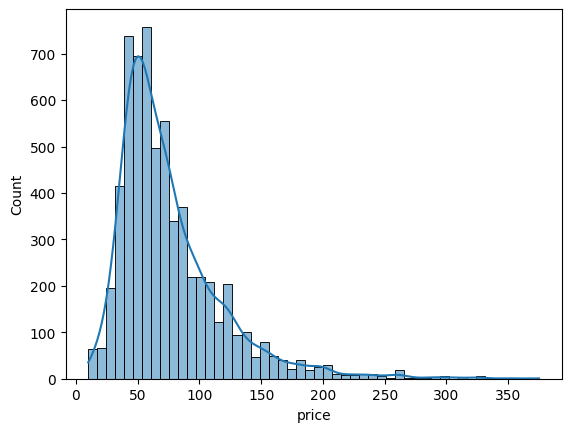

In [ ]:
# Histogram of price
sns.histplot(data['price'], bins=50, kde=True)
plt.show()

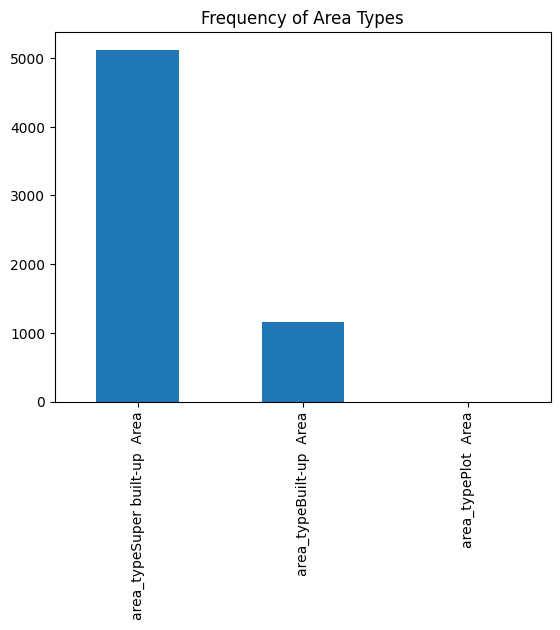

In [ ]:
area_cols = ['area_typeSuper built-up  Area',
             'area_typeBuilt-up  Area',
             'area_typePlot  Area']

data[area_cols].sum().plot(kind='bar')
plt.title("Frequency of Area Types")
plt.show()

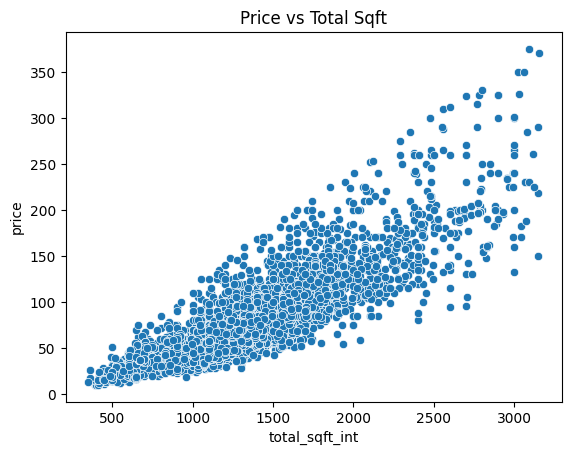

In [ ]:
sns.scatterplot(x='total_sqft_int', y='price', data=data)
plt.title("Price vs Total Sqft")
plt.show()

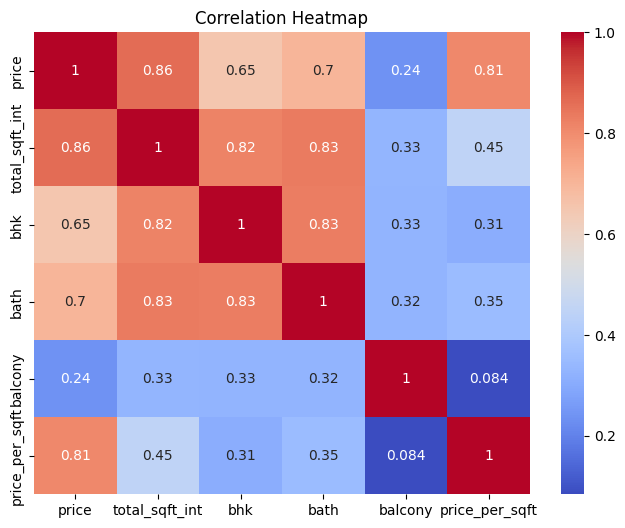

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data[['price','total_sqft_int','bhk','bath','balcony','price_per_sqft']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

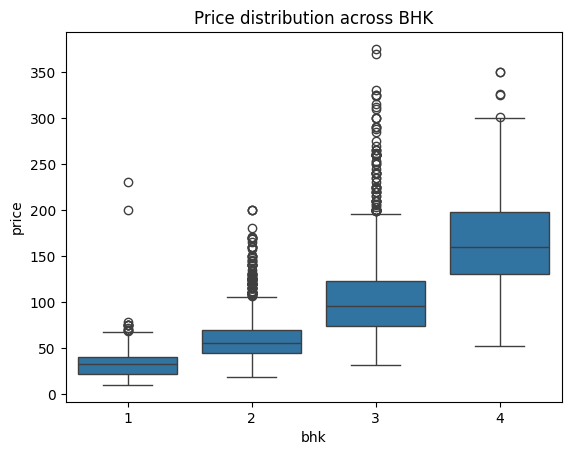

In [ ]:
sns.boxplot(x='bhk', y='price', data=data)
plt.title("Price distribution across BHK")
plt.show()

# Specifying X and y

In [ ]:
X = data.drop(['price'],axis=1)
y = data['price']

In [ ]:
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (6314, 9)
Shape of y: (6314,)


# Splitting dataset into training and testing set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Decision Tree Regression Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

## Instantiating the model

In [ ]:
my_model = DecisionTreeRegressor()

## Training the model

In [ ]:
my_model.fit(X_train,y_train)

DecisionTreeRegressor()

## Predicting test results

In [ ]:
y_pred = my_model.predict(X_test)
y_pred

array([ 25.79,  33.5 , 150.  , ...,  58.  ,  30.24,  57.5 ])

In [ ]:
y_test

,price
3761,25.530
2101,33.500
6946,150.000
5234,22.000
2173,57.000
...,...
1294,46.000
2865,139.000
7062,58.000
6032,30.715


## Evaluating the model

## 1. Mean Absolute Error (MAE)

**Formula**  
$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**What it measures**  
Average absolute difference between actual values $y_i$ and predictions $\hat{y}_i$. It tells you how far off, on average, your predictions are in the original units of the target.


**Properties**
- Units: same as target (interpretable).
- Robustness: less sensitive to large outliers than MSE/RMSE.
- Optimization: MAE corresponds to minimizing the L₁ loss. The optimal constant predictor under MAE is the **median** of the targets.
- Differentiability: absolute value is not differentiable at 0, but subgradients exist (usable with optimization methods that handle subgradients).

**When to use**
- When you want an interpretable average error and want reduced influence of outliers.
- When large errors shouldn’t be penalized quadratically.

**Pros / Cons**
- Intuitive, robust to outliers.
- Not differentiable at 0 (practical training considerations), treats all errors linearly so huge errors are not punished much.

---

## 2. Mean Squared Error (MSE)

**Formula**  
$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**What it measures**  
Average of squared differences between actuals and predictions.

**Intuition**  
By squaring errors, MSE severely penalizes large deviations. If you care more about big mistakes, MSE will emphasize them.

**Properties**
- Units: squared units of the target (less interpretable).
- Optimization: smooth, differentiable; MSE corresponds to L₂ loss. The optimal constant predictor under MSE is the **mean** of the targets.
- Relationship to variance & bias: for an estimator $\hat{f}$ the expected squared error decomposes into:
  $$
  \mathbb{E}[(y - \hat{f}(x))^2] = \text{Irreducible noise} + \text{Bias}^2 + \text{Variance}.
  $$
- Influence: strongly influenced by outliers (because of squaring).

**When to use**
- When large errors are especially bad and should be penalized.
- When using gradient-based optimizers (smoothness helps).

**Pros / Cons**
- Differentiable and convenient for optimization; ties into bias-variance theory.
- Sensitive to outliers; units are squared so less direct interpretability.

---

## 3. Root Mean Squared Error (RMSE)

**Formula**  
$$
\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

**What it measures**  
Square root of average squared error — returns the error in original units (same units as the target).

**Intuition**  
RMSE is the standard deviation of the prediction errors (residuals). It gives a sense of the *typical magnitude* of an error with big errors weighted more heavily.

**Properties**
- Units: same as target (interpretable).
- Preference vs MAE: RMSE > MAE when errors vary; if error distribution has large tails, RMSE increases more.
- Optimization: like MSE (same gradient up to scalar).

**When to use**
- When you want an interpretable metric (units) but still penalize large errors.
- Common default metric for many regression tasks.

**Pros / Cons**
- Interpretable (same units) and highlights large errors.
- Sensitive to outliers.

---

## 4. R² — Coefficient of Determination

**Formula (sample form)**  
$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
= 1 - \frac{\text{SSE}}{\text{SST}}
$$
where $\bar{y}$ is the mean of the observed targets, SSE = sum squared errors, SST = total sum of squares.

**What it measures**  
Proportion of the variance in the target that is explained by the model. R² = 1 means perfect prediction; R² = 0 means model is no better than predicting the mean; R² < 0 means model is worse than predicting the mean.

**Intuition**  
If R² = 0.80 → model explains 80% of the variance in the target.

**Properties**
- Unitless, normalized between $ -\infty$ and 1.
- Sensitive to model fit relative to the baseline mean predictor.
- Adjusted R² compensates for number of predictors:
  $$
  R^2_{\text{adj}} = 1 - (1-R^2)\frac{n-1}{n-p-1}
  $$
  where $p$ is number of predictors; useful for comparing models with different numbers of features.

**When to use**
- To report proportion of variance explained — good for interpretability across scales.
- Use in conjunction with absolute error metrics (MAE/RMSE) — R² doesn’t convey magnitude of errors.

**Pros / Cons**
- Unitless and comparable across datasets of same response scale.
- Can be misleading for non-linear models or non-constant-variance errors; does not show magnitude of errors; can be negative.

---

## Understand with a numeric example

Given:
- $y = [3, -0.5, 2, 7]$  
- $\hat{y} = [2.5, 0.0, 2, 8]$

**Step 1 — errors**  
$e = y - \hat{y} = [0.5, -0.5, 0.0, -1.0]$

**Step 2 — absolute errors and squared errors**  
$|e| = [0.5, 0.5, 0.0, 1.0]$  
$e^2 = [0.25, 0.25, 0.0, 1.0]$

**MAE**  
$$
\text{MAE} = \frac{0.5 + 0.5 + 0 + 1.0}{4} = \frac{2.0}{4} = 0.5
$$

**MSE**  
$$
\text{MSE} = \frac{0.25 + 0.25 + 0 + 1.0}{4} = \frac{1.5}{4} = 0.375
$$

**RMSE**  
$$
\text{RMSE} = \sqrt{0.375} \approx 0.6123724357
$$

**R²**  
Compute mean $\bar{y} = \frac{3 + (-0.5) + 2 + 7}{4} = \frac{11.5}{4} = 2.875.$  
SST = $\sum (y_i - \bar{y})^2 = 29.1875$.  
SSE = sum of squared residuals = 1.5.  
$$
R^2 = 1 - \frac{1.5}{29.1875} = 1 - \frac{24}{467} \approx 0.9486081370
$$

So the numeric results are:
- **MAE = 0.5**  
- **MSE = 0.375**  
- **RMSE ≈ 0.6124**  
- **R² ≈ 0.9486**

---


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.13409342834521


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 8.242494734758512


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.870974527013173


In [ ]:
r2_score(y_test,y_pred)

0.99532959495177

# Plotting Actual vs Predicted Values

Text(0.5, 1.0, 'Actual vs Predicted')

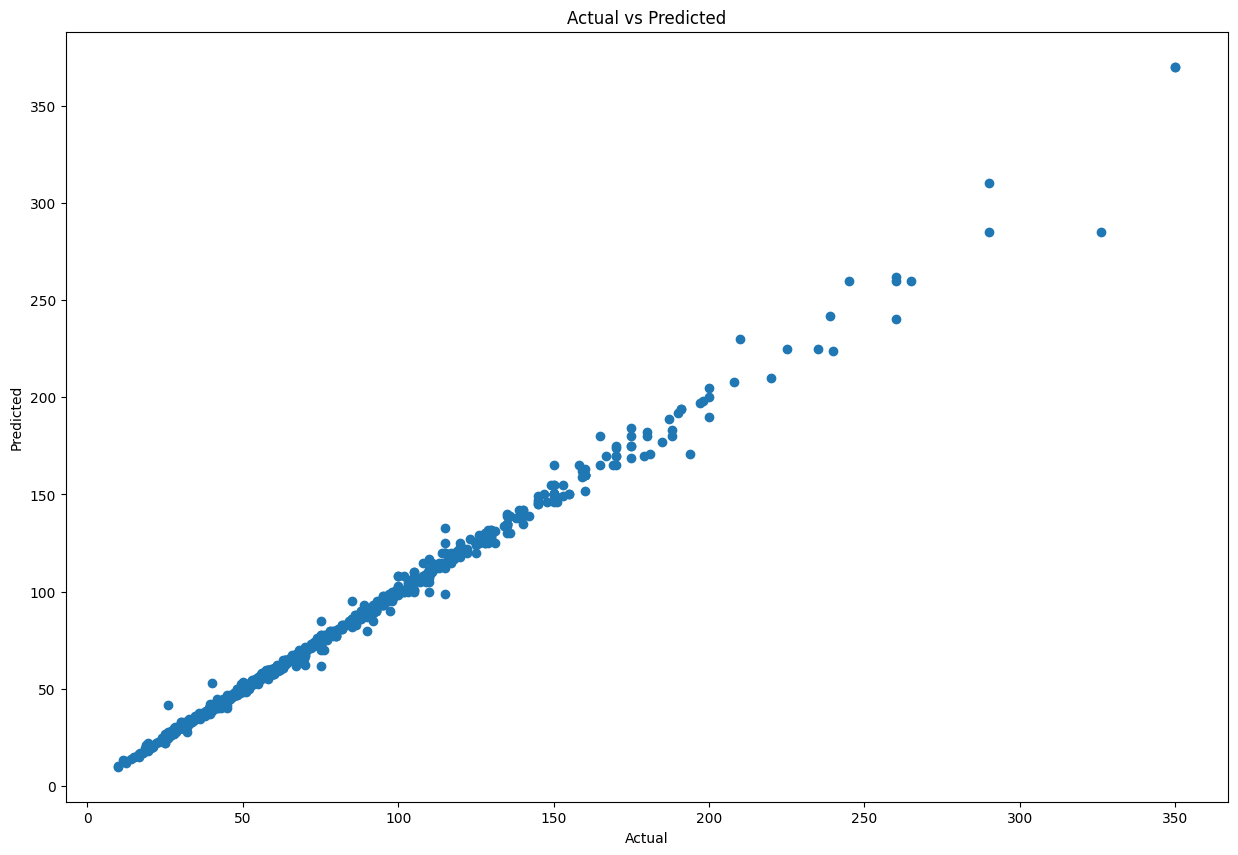

In [ ]:
plt.figure(figsize=(15,10))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title('Actual vs Predicted')

# Printing Actual vs Predicted Values

In [ ]:
pred_y_df = pd.DataFrame({'Actual Values':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_y_df[0:20]

,Actual Values,Predicted Value,Difference
3761,25.53,25.790,-0.260
2101,33.50,33.500,0.000
6946,150.00,150.000,0.000
5234,22.00,22.000,0.000
2173,57.00,56.725,0.275
1114,103.00,104.000,-1.000
5855,75.00,75.000,0.000
3088,75.00,75.000,0.000
3554,60.00,60.000,0.000
1736,58.00,58.000,0.000


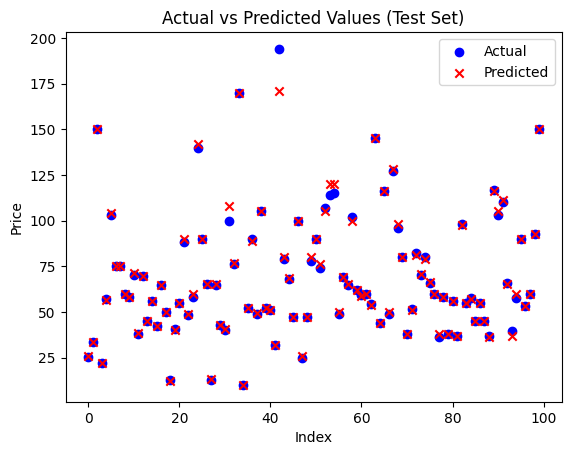

In [ ]:
x1 = [i for i in range(100)]
y1=y_test[:100]
y2=y_pred[:100]
plt.scatter(x=x1,y=y1, label='Actual', color='blue', marker='o' )
plt.scatter(x=x1,y=y2, label='Predicted', color='red', marker='x')

plt.title("Actual vs Predicted Values (Test Set)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()
plt.show()

                                                                  --- THE END ---